In [1]:
# 模块1：导入依赖并固定随机种子
import pickle as pkl
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)


c:\Users\zijeff\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 模块2：配置参数与路径
class Config:
    root_dir = Path('.')
    data_dir = root_dir / 'Data'
    artifact_dir = root_dir / 'saved_dict'
    figure_dir = root_dir / 'figures'
    train_path = data_dir / 'train.txt'
    dev_path = data_dir / 'dev.txt'
    test_path = data_dir / 'test.txt'
    class_path = data_dir / 'class.txt'
    project_vocab_path = data_dir / 'vocab.pkl'
    notebook_vocab_path = artifact_dir / 'my_textcnn_vocab.pkl'
    pretrained_embedding_path = data_dir / 'embedding_SougouNews.npz'
    save_path = artifact_dir / 'my_TextCNN.pt'
    loss_curve_path = figure_dir / 'TextCNN_loss_curve.png'

    # 是否按词切分；False 表示按字符切分
    use_word = False
    # 是否使用预训练词向量；当前默认关闭，直接随机初始化词向量
    use_pretrained_embedding = False
    # 词表大小上限、最小词频和统一截断/补齐长度
    max_vocab_size = 10000
    min_freq = 1
    pad_size = 32

    # 训练相关超参数
    dropout = 0.5
    num_epochs = 10
    batch_size = 128
    learning_rate = 1e-3
    # 词向量维度、卷积核尺寸，以及每种卷积核的输出通道数
    embedding_dim = 300
    filter_sizes = (2, 3, 4)
    num_filters = 256

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


config = Config()
config.save_path.parent.mkdir(parents=True, exist_ok=True)
config.figure_dir.mkdir(parents=True, exist_ok=True)

with open(config.class_path, 'r', encoding='utf-8') as f:
    class_names = [line.strip() for line in f if line.strip()]

print(f'Classes: {class_names}')
print(f'Device: {config.device}')
print(f'Use pretrained embedding: {config.use_pretrained_embedding}')


Classes: ['finance', 'realty', 'education', 'science']
Device: cpu
Use pretrained embedding: False


In [3]:
# 模块3：读取数据、构建词表，并按需加载预训练词向量
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'


def tokenize(text):
    text = text.strip()
    return text.split() if config.use_word else list(text)


def read_samples(path):
    samples = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            if not line:
                continue
            text, label = line.rsplit('\t', 1)
            tokens = tokenize(text)
            if not tokens:
                tokens = [UNK_TOKEN]
            samples.append((tokens, int(label), text))
    return samples


def build_vocab(samples, max_vocab_size=10000, min_freq=1):
    counter = Counter()
    for tokens, _, _ in samples:
        counter.update(tokens)

    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for token, freq in counter.most_common(max_vocab_size - len(vocab)):
        if freq < min_freq:
            continue
        vocab[token] = len(vocab)
    return vocab


# 分别读取训练集、验证集和测试集
train_samples = read_samples(config.train_path)
dev_samples = read_samples(config.dev_path)
test_samples = read_samples(config.test_path)

vocab_source = 'built_from_train'
# 如果存在项目词表并启用了预训练词向量，则优先复用项目词表
if config.use_pretrained_embedding and config.project_vocab_path.exists():
    with open(config.project_vocab_path, 'rb') as f:
        vocab = pkl.load(f)
    vocab_source = 'project_vocab'
else:
    vocab = build_vocab(train_samples, config.max_vocab_size, config.min_freq)
    with open(config.notebook_vocab_path, 'wb') as f:
        pkl.dump(vocab, f)

# 只有在启用预训练词向量时才加载对应矩阵
pretrained_embedding = None
if config.use_pretrained_embedding:
    pretrained_embedding = np.load(config.pretrained_embedding_path)['embeddings'].astype(np.float32)
    if pretrained_embedding.shape[0] != len(vocab):
        raise ValueError('The pretrained embedding rows do not match the current vocab size.')
    config.embedding_dim = int(pretrained_embedding.shape[1])

print(f'Train size: {len(train_samples)}')
print(f'Dev size: {len(dev_samples)}')
print(f'Test size: {len(test_samples)}')
print(f'Vocab source: {vocab_source}')
print(f'Vocab size: {len(vocab)}')
print(f'Embedding dim: {config.embedding_dim}')
print(f'Sample text: {train_samples[0][2]}')
print(f'Sample label id: {train_samples[0][1]} -> {class_names[train_samples[0][1]]}')


Train size: 2000
Dev size: 400
Test size: 400
Vocab source: built_from_train
Vocab size: 2131
Embedding dim: 300
Sample text: 国际能源机构上调全球原油需求预期
Sample label id: 0 -> finance


In [4]:
# 模块4：定义数据集与 DataLoader
class NewsDataset(Dataset):
    def __init__(self, samples, vocab):
        self.samples = samples
        self.vocab = vocab

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        tokens, label, raw_text = self.samples[idx]
        ids = [self.vocab.get(token, self.vocab[UNK_TOKEN]) for token in tokens]
        seq_len = min(len(ids), config.pad_size)

        # TextCNN 需要固定长度输入，因此这里统一做截断或补齐
        if len(ids) < config.pad_size:
            ids = ids + [self.vocab[PAD_TOKEN]] * (config.pad_size - len(ids))
        else:
            ids = ids[: config.pad_size]

        return {
            'input_ids': ids,
            'seq_len': seq_len,
            'label': label,
            'raw_text': raw_text,
        }


def collate_fn(batch):
    input_ids = torch.tensor([item['input_ids'] for item in batch], dtype=torch.long)
    seq_lens = torch.tensor([item['seq_len'] for item in batch], dtype=torch.long)
    labels = torch.tensor([item['label'] for item in batch], dtype=torch.long)
    raw_texts = [item['raw_text'] for item in batch]
    return (input_ids, seq_lens), labels, raw_texts


train_dataset = NewsDataset(train_samples, vocab)
dev_dataset = NewsDataset(dev_samples, vocab)
test_dataset = NewsDataset(test_samples, vocab)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, collate_fn=collate_fn)
dev_loader = DataLoader(dev_dataset, batch_size=config.batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, collate_fn=collate_fn)

batch_inputs, batch_labels, _ = next(iter(train_loader))
print(batch_inputs[0].shape, batch_inputs[1].shape, batch_labels.shape)


torch.Size([128, 32]) torch.Size([128]) torch.Size([128])


In [5]:
# 模块5：定义 TextCNN 模型
class TextCNN(nn.Module):
    def __init__(self, vocab_size, num_classes, pad_idx, pretrained_embedding=None):
        super().__init__()
        # 词向量层：可选择加载预训练词向量，也可以随机初始化
        if pretrained_embedding is not None:
            self.embedding = nn.Embedding.from_pretrained(
                torch.tensor(pretrained_embedding),
                freeze=False,
            )
        else:
            self.embedding = nn.Embedding(vocab_size, config.embedding_dim, padding_idx=pad_idx)

        # 使用不同尺寸的卷积核提取不同 n-gram 特征
        self.convs = nn.ModuleList([
            nn.Conv2d(1, config.num_filters, (kernel_size, config.embedding_dim))
            for kernel_size in config.filter_sizes
        ])
        self.dropout = nn.Dropout(config.dropout)
        self.fc = nn.Linear(config.num_filters * len(config.filter_sizes), num_classes)

    # 卷积后接最大池化，保留每个卷积核最显著的特征
    def conv_and_pool(self, x, conv):
        x = F.relu(conv(x)).squeeze(3)
        x = F.max_pool1d(x, x.size(2)).squeeze(2)
        return x

    # 前向传播：词嵌入 -> 卷积池化 -> 拼接 -> dropout -> 全连接分类
    def forward(self, batch_inputs):
        input_ids, _ = batch_inputs
        out = self.embedding(input_ids)
        out = out.unsqueeze(1)
        out = torch.cat([self.conv_and_pool(out, conv) for conv in self.convs], dim=1)
        out = self.dropout(out)
        logits = self.fc(out)
        return logits


model = TextCNN(
    vocab_size=len(vocab),
    num_classes=len(class_names),
    pad_idx=vocab[PAD_TOKEN],
    pretrained_embedding=pretrained_embedding,
).to(config.device)

print(model)


TextCNN(
  (embedding): Embedding(2131, 300, padding_idx=0)
  (convs): ModuleList(
    (0): Conv2d(1, 256, kernel_size=(2, 300), stride=(1, 1))
    (1): Conv2d(1, 256, kernel_size=(3, 300), stride=(1, 1))
    (2): Conv2d(1, 256, kernel_size=(4, 300), stride=(1, 1))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=768, out_features=4, bias=True)
)


In [6]:
# 模块6：参数初始化、训练与评估函数
def init_network(model, method='xavier', exclude='embedding'):
    for name, param in model.named_parameters():
        if exclude in name:
            continue
        if 'weight' in name:
            if method == 'xavier':
                nn.init.xavier_normal_(param)
            elif method == 'kaiming':
                nn.init.kaiming_normal_(param)
            else:
                nn.init.normal_(param)
        elif 'bias' in name:
            nn.init.constant_(param, 0)


init_network(model)
# 多分类任务使用交叉熵损失，优化器使用 Adam
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)


# 单轮训练或验证；当 optimizer 为 None 时只进行评估
def run_epoch(model, data_loader, optimizer=None):
    is_train = optimizer is not None
    if is_train:
        model.train()
    else:
        model.eval()

    loss_list = []
    pred_list = []
    label_list = []

    progress = tqdm(data_loader, leave=False)
    for batch_inputs, labels, _ in progress:
        input_ids, seq_lens = batch_inputs
        input_ids = input_ids.to(config.device)
        seq_lens = seq_lens.to(config.device)
        labels = labels.to(config.device)

        batch_inputs = (input_ids, seq_lens)

        with torch.set_grad_enabled(is_train):
            logits = model(batch_inputs)
            loss = criterion(logits, labels)

            if is_train:
                # 训练阶段执行梯度清零、反向传播和参数更新
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        preds = torch.argmax(logits, dim=1)
        loss_list.append(loss.item())
        pred_list.extend(preds.detach().cpu().tolist())
        label_list.extend(labels.detach().cpu().tolist())

        if is_train:
            progress.set_description(f'train loss={loss.item():.4f}')
        else:
            progress.set_description(f'eval loss={loss.item():.4f}')

    avg_loss = float(np.mean(loss_list))
    avg_acc = accuracy_score(label_list, pred_list)
    return avg_loss, avg_acc, label_list, pred_list


Epoch 01 | train loss=0.6803, train acc=0.7330 | dev loss=0.4105, dev acc=0.8400
Best model saved to: saved_dict\my_TextCNN.pt


Epoch 02 | train loss=0.1624, train acc=0.9535 | dev loss=0.3441, dev acc=0.8750
Best model saved to: saved_dict\my_TextCNN.pt


Epoch 03 | train loss=0.0675, train acc=0.9845 | dev loss=0.3671, dev acc=0.8750


Epoch 04 | train loss=0.0348, train acc=0.9945 | dev loss=0.3466, dev acc=0.8850


Epoch 05 | train loss=0.0213, train acc=0.9980 | dev loss=0.3768, dev acc=0.8825


Epoch 06 | train loss=0.0142, train acc=1.0000 | dev loss=0.3577, dev acc=0.8750


Epoch 07 | train loss=0.0115, train acc=0.9985 | dev loss=0.3636, dev acc=0.8850


Epoch 08 | train loss=0.0082, train acc=0.9990 | dev loss=0.3910, dev acc=0.8700


Epoch 09 | train loss=0.0080, train acc=1.0000 | dev loss=0.3687, dev acc=0.8875


Epoch 10 | train loss=0.0075, train acc=0.9990 | dev loss=0.3858, dev acc=0.8900
Loss curve saved to: figures\TextCNN_loss_curve.png


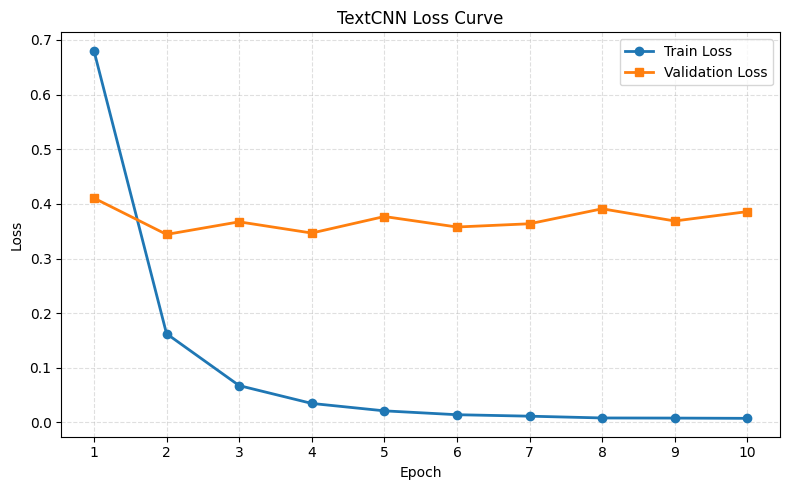

Test loss: 0.2836
Test acc: 0.8875
              precision    recall  f1-score   support

     finance     0.8778    0.7900    0.8316       100
      realty     0.9271    0.8900    0.9082       100
   education     0.9216    0.9400    0.9307       100
     science     0.8304    0.9300    0.8774       100

    accuracy                         0.8875       400
   macro avg     0.8892    0.8875    0.8869       400
weighted avg     0.8892    0.8875    0.8869       400

[[79  6  2 13]
 [ 6 89  3  2]
 [ 1  1 94  4]
 [ 4  0  3 93]]


In [7]:
# 模块7：训练循环、loss 曲线绘制与最终测试
best_dev_loss = float('inf')
# history 用于记录每个 epoch 的训练/验证指标，便于后续画图分析
history = []

for epoch in range(1, config.num_epochs + 1):
    # 每轮先在训练集更新参数，再在验证集上评估泛化表现
    train_loss, train_acc, _, _ = run_epoch(model, train_loader, optimizer=optimizer)
    dev_loss, dev_acc, _, _ = run_epoch(model, dev_loader, optimizer=None)

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'dev_loss': dev_loss,
        'dev_acc': dev_acc,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train loss={train_loss:.4f}, train acc={train_acc:.4f} | "
        f"dev loss={dev_loss:.4f}, dev acc={dev_acc:.4f}"
    )

    # TextCNN 以验证集 loss 最低作为最优模型保存标准
    if dev_loss < best_dev_loss:
        best_dev_loss = dev_loss
        torch.save(model.state_dict(), config.save_path)
        print(f'Best model saved to: {config.save_path}')

# 根据 history 绘制训练集和验证集的 loss 变化曲线
epochs = [record['epoch'] for record in history]
train_losses = [record['train_loss'] for record in history]
dev_losses = [record['dev_loss'] for record in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', linewidth=2, label='Train Loss')
plt.plot(epochs, dev_losses, marker='s', linewidth=2, label='Validation Loss')
plt.title('TextCNN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(config.loss_curve_path, dpi=300, bbox_inches='tight')
print(f'Loss curve saved to: {config.loss_curve_path}')
plt.show()

# 载入验证集表现最好的模型，再在测试集上做最终评估
model.load_state_dict(torch.load(config.save_path, map_location=config.device))
test_loss, test_acc, test_labels, test_preds = run_epoch(model, test_loader, optimizer=None)

print(f'Test loss: {test_loss:.4f}')
print(f'Test acc: {test_acc:.4f}')
print(classification_report(
    test_labels,
    test_preds,
    labels=list(range(len(class_names))),
    target_names=class_names,
    digits=4,
))
print(confusion_matrix(test_labels, test_preds))

In [8]:
# 模块8：单条文本预测函数
def predict_text(text):
    model.eval()
    tokens = tokenize(text)
    if not tokens:
        tokens = [UNK_TOKEN]

    ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens]
    seq_len = min(len(ids), config.pad_size)

    if len(ids) < config.pad_size:
        ids = ids + [vocab[PAD_TOKEN]] * (config.pad_size - len(ids))
    else:
        ids = ids[: config.pad_size]

    input_ids = torch.tensor([ids], dtype=torch.long).to(config.device)
    seq_lens = torch.tensor([seq_len], dtype=torch.long).to(config.device)

    with torch.no_grad():
        logits = model((input_ids, seq_lens))
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    label_id = int(np.argmax(probs))
    return {
        'text': text,
        'label_id': label_id,
        'label_name': class_names[label_id],
        'probabilities': {class_names[i]: float(probs[i]) for i in range(len(class_names))},
    }


example = test_samples[0][2]
predict_text(example)


{'text': '供应真紧张棉价很凶猛',
 'label_id': 0,
 'label_name': 'finance',
 'probabilities': {'finance': 0.7917313575744629,
  'realty': 0.1629132181406021,
  'education': 0.0054228706285357475,
  'science': 0.039932552725076675}}